In [151]:
import numpy as np
import matplotlib.pyplot as plt

In [152]:
data = np.genfromtxt("galaxyquasar.csv", delimiter=",", names=True, dtype=None, encoding='utf-8')

In [153]:
print(data)

[(18.97213, 18.53676, 18.5828 , 18.34936, 18.29215, 'QSO', 0.5228189 , 1.547483e-04)
 (19.24592, 17.47646, 16.47817, 16.04472, 15.68851, 'GALAXY', 0.1228459 , 2.816076e-05)
 (19.43536, 17.70268, 16.91565, 16.58327, 16.39128, 'GALAXY', 0.        , 0.000000e+00)
 ...
 (18.62718, 17.30876, 16.87371, 16.62399, 16.42296, 'GALAXY', 0.05442934, 8.433598e-06)
 (19.5514 , 18.27711, 17.62101, 17.21947, 17.03347, 'GALAXY', 0.1125709 , 9.286238e-06)
 (18.80772, 17.75751, 17.405  , 17.2165 , 17.12295, 'GALAXY', 0.04365238, 7.415751e-06)]


In [154]:
print(data.dtype.names)

('u', 'g', 'r', 'i', 'z', 'class', 'z1', 'zerr')


In [155]:
ug = [x[0] - x[1] for x in data]
gr = [x[1] - x[2] for x in data]
ri = [x[2] - x[3] for x in data]
iz = [x[3] - x[4] for x in data]

In [156]:
print(len(ug))
lab = [0 if x[5] == "GALAXY" else 1 for x in data]

50000


In [157]:
data = np.stack((ug, gr, ri, iz, lab), axis=1)
gal = np.array([x for x in data if x[4]==0])
qua = np.array([x for x in data if x[4]==1])

In [158]:
print(data)

[[ 0.43537 -0.04604  0.23344  0.05721  1.     ]
 [ 1.76946  0.99829  0.43345  0.35621  0.     ]
 [ 1.73268  0.78703  0.33238  0.19199  0.     ]
 ...
 [ 1.31842  0.43505  0.24972  0.20103  0.     ]
 [ 1.27429  0.6561   0.40154  0.186    0.     ]
 [ 1.05021  0.35251  0.1885   0.09355  0.     ]]


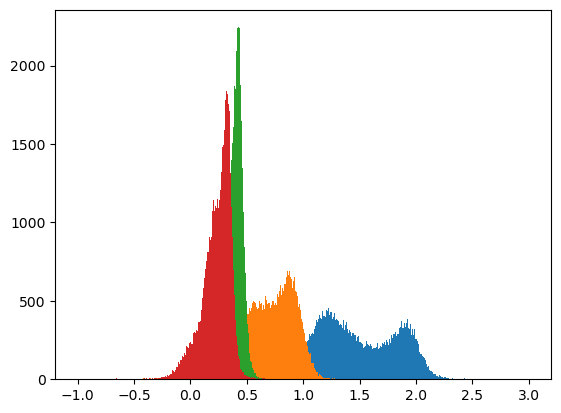

In [159]:
b = np.linspace(-1, 3, 500)
plt.hist(data[:,0], bins=b)
plt.hist(data[:,1], bins=b)
plt.hist(data[:,2], bins=b)
plt.hist(data[:,3], bins=b);

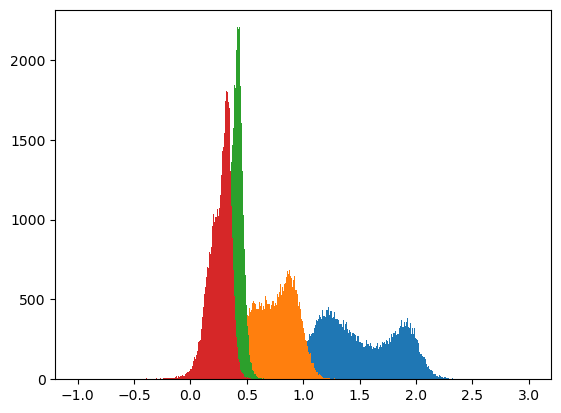

In [160]:
plt.hist(gal[:,0], bins=b)
plt.hist(gal[:,1], bins=b)
plt.hist(gal[:,2], bins=b)
plt.hist(gal[:,3], bins=b);

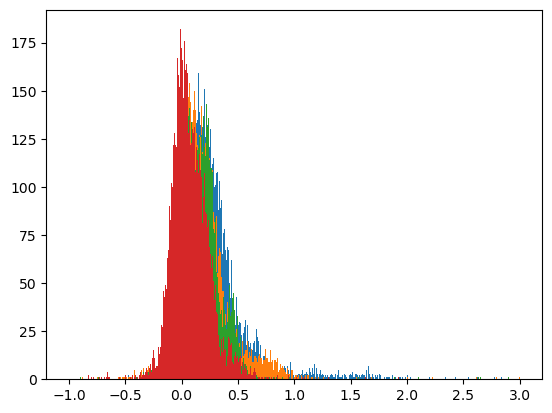

In [161]:
plt.hist(qua[:,0], bins=b)
plt.hist(qua[:,1], bins=b)
plt.hist(qua[:,2], bins=b)
plt.hist(qua[:,3], bins=b);

In [162]:
np.random.shuffle(data)             #non so se serve, strano che non si debba usare data = np.random.shuffle(data)
train = 40000
validation = 50000 - train
data_train = data[:train]
data_validation = data[-validation:]

In [163]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve

In [164]:
#print(data_train[:,0])

In [165]:
#print(data_train[:,0].reshape(-1, 1))
#gnb.fit error
#ValueError: Expected 2D array, got 1D array instead:
#array=[1.36886 1.22706 0.39728 ... 1.23249 1.58784 1.56773].
#Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

[1.99999996e+00 9.99999957e-01 9.99999173e-01 9.99886633e-01
 9.99689611e-01 9.99670859e-01 9.99612982e-01 9.98751542e-01
 9.98739105e-01 9.97617184e-01 9.97615243e-01 9.97606485e-01
 9.96512496e-01 9.96492345e-01 9.95853949e-01 9.95833331e-01
 9.94908712e-01 9.94895581e-01 9.94313474e-01 9.94238121e-01
 9.92425081e-01 9.92404731e-01 9.90464696e-01 9.90462287e-01
 9.89858870e-01 9.89838329e-01 9.89126061e-01 9.89117796e-01
 9.89075455e-01 9.89044052e-01 9.88624474e-01 9.88597533e-01
 9.88319601e-01 9.88301818e-01 9.85532336e-01 9.85531110e-01
 9.84176507e-01 9.84111909e-01 9.83714534e-01 9.83629969e-01
 9.80106073e-01 9.80102688e-01 9.77920609e-01 9.77828336e-01
 9.77463027e-01 9.77457272e-01 9.75263216e-01 9.74987894e-01
 9.74586462e-01 9.74441069e-01 9.73717193e-01 9.73681362e-01
 9.69942958e-01 9.69935281e-01 9.68588056e-01 9.68534542e-01
 9.59869522e-01 9.59760347e-01 9.52727290e-01 9.52522794e-01
 9.32846255e-01 9.32711288e-01 9.21650935e-01 9.21455610e-01
 9.14965189e-01 9.140122

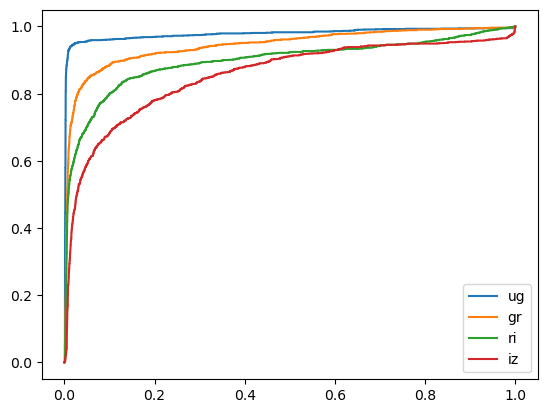

In [ ]:
gnb = GaussianNB()
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    print(thresh)       #2-1-0.999-....-0.8-....0.7-....
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

In [167]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

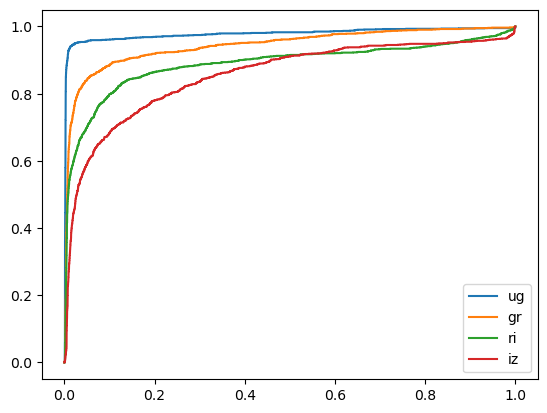

In [168]:
gnb = LDA()                     #è rimasto gnb per copia incolla
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

#almeno qui il verde va un pochino sotto il rosso

In [169]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

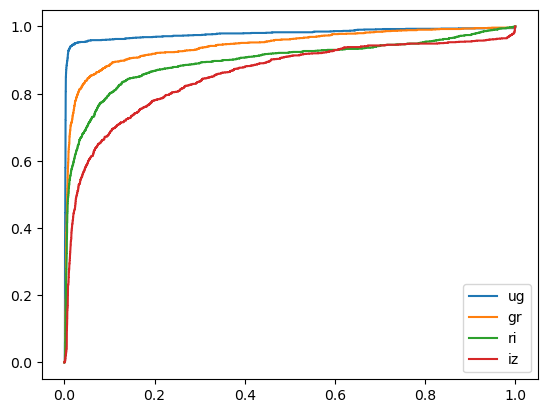

In [170]:
gnb = QDA()
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()

In [171]:
from sklearn.neighbors import KNeighborsClassifier

[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]
[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]
[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]
[2.  1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 0. ]


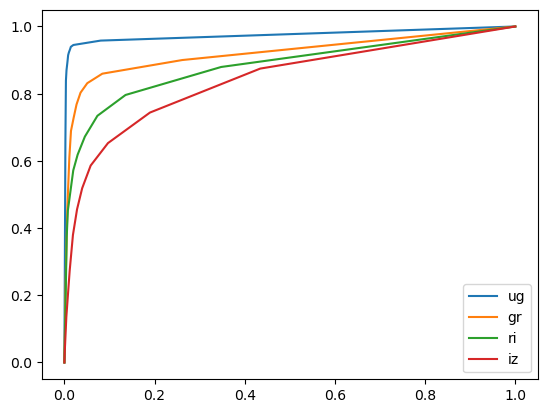

In [172]:
gnb = KNeighborsClassifier(10)
lab = ["ug", "gr", "ri", "iz"]
for i in range(4):
    gnb.fit(data_train[:,i].reshape(-1, 1), data_train[:,4])
    y_prob = gnb.predict_proba(data_validation[:,i].reshape(-1, 1))[:,1]
    #print(y_prob)

    fpr, tpr, thresh = roc_curve(data_validation[:,4], y_prob)
    print(thresh)
    plt.plot(fpr, tpr, label=lab[i])

plt.legend()